<a href="https://colab.research.google.com/github/24Priyanshi/period-tracker/blob/main/data_vol2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [17]:
!pip install -q missingno

In [18]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.impute import KNNImputer

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.3f}".format)

In [4]:
DATA_DIR   = Path("/content/drive/MyDrive/MensturalTracker")
OUTPUT_DIR = Path("/content/drive/MyDrive/MensturalTracker/outputs")
OUTPUT_DIR.mkdir(exist_ok=True)


In [6]:
plt.rcParams.update({
    "figure.facecolor" : "#0f0f14",
    "axes.facecolor"   : "#1a1a24",
    "axes.edgecolor"   : "#3a3a4a",
    "axes.labelcolor"  : "#e0dff0",
    "xtick.color"      : "#a0a0b8",
    "ytick.color"      : "#a0a0b8",
    "text.color"       : "#e0dff0",
    "grid.color"       : "#2a2a3a",
    "grid.linestyle"   : "--",
    "grid.alpha"       : 0.5,
})
ACCENT  = "#c084fc"
ACCENT2 = "#f472b6"
ACCENT3 = "#34d399"
PALETTE = [ACCENT, ACCENT2, ACCENT3, "#60a5fa", "#fbbf24", "#f87171"]

print("✓  Config ready")
print(f"   Data  → {DATA_DIR}")
print(f"   Output → {OUTPUT_DIR}")


✓  Config ready
   Data  → /content/drive/MyDrive/MensturalTracker
   Output → /content/drive/MyDrive/MensturalTracker/outputs


In [7]:
FILE_MAP = {
    "active_minutes"             : "active_minutes.csv",
    "active_zone_minutes"        : "active_zone_minutes.csv",
    "altitude"                   : "altitude.csv",
    "computed_temperature"       : "computed_temperature.csv",
    "demographic_vo2_max"        : "demographic_vo2_max.csv",
    "estimated_oxygen_variation" : "estimated_oxygen_variation.csv",
    "exercise"                   : "exercise.csv",
    "glucose"                    : "glucose.csv",
    "hrv_details"                : "heart_rate_variability_details.csv",
    "height_weight"              : "height_and_weight.csv",
    "hormones"                   : "hormones_and_selfreport.csv",
    "respiratory_rate"           : "respiratory_rate_summary.csv",
    "resting_hr"                 : "resting_heart_rate.csv",
    "sleep_score"                : "sleep_score.csv",
    "sleep"                      : "sleep.csv",
    "steps"                      : "steps.csv",
    "stress_score"               : "stress_score.csv",
    "subject_info"               : "subject-info.csv",
    "time_in_hr_zones"           : "time_in_heart_rate_zones.csv",
}

DATE_KEYWORDS = ("date", "time", "timestamp", "datetime", "start", "end",
                 "recorded", "logged", "created")
PID_KEYWORDS  = ("participant_id", "participant", "subject_id", "subject",
                 "pid", "id", "user_id", "user")

def detect_date_cols(columns):
    return [c for c in columns if any(k in c.lower() for k in DATE_KEYWORDS)]

def detect_pid_col(columns):
    cols_lower = [c.lower() for c in columns]
    for kw in PID_KEYWORDS:
        if kw in cols_lower:
            return columns[cols_lower.index(kw)]
    return None

dfs = {}
missing_files = []

for key, fname in FILE_MAP.items():
    path = DATA_DIR / fname
    if not path.exists():
        missing_files.append(fname)
        continue

    df = pd.read_csv(path)

    # Auto-detect & parse date columns
    date_cols = detect_date_cols(df.columns.tolist())
    for dc in date_cols:
        df[dc] = pd.to_datetime(df[dc], errors="coerce", utc=True)
    if date_cols and date_cols[0] != "date":
        df.rename(columns={date_cols[0]: "date"}, inplace=True)

    # Auto-detect & rename participant ID
    pid_col = detect_pid_col(df.columns.tolist())
    if pid_col and pid_col != "participant_id":
        df.rename(columns={pid_col: "participant_id"}, inplace=True)

    dfs[key] = df
    print(f"  ✓  {fname:<45}  shape={df.shape}")

print(f"\nLoaded  : {len(dfs)} files")
if missing_files:
    print(f"Missing : {missing_files}")


  ✓  active_minutes.csv                             shape=(5552, 8)
  ✓  active_zone_minutes.csv                        shape=(154482, 7)
  ✓  altitude.csv                                   shape=(90878, 6)
  ✓  computed_temperature.csv                       shape=(5575, 14)
  ✓  demographic_vo2_max.csv                        shape=(11482, 8)
  ✓  estimated_oxygen_variation.csv                 shape=(3070312, 6)
  ✓  exercise.csv                                   shape=(7282, 26)
  ✓  glucose.csv                                    shape=(837130, 6)
  ✓  heart_rate_variability_details.csv             shape=(436262, 9)
  ✓  height_and_weight.csv                          shape=(42, 5)
  ✓  hormones_and_selfreport.csv                    shape=(5659, 22)
  ✓  respiratory_rate_summary.csv                   shape=(6301, 17)
  ✓  resting_heart_rate.csv                         shape=(13737, 6)
  ✓  sleep_score.csv                                shape=(5308, 12)
  ✓  sleep.csv                   

In [20]:
import os
from pathlib import Path

DATA_DIR = Path("/content/drive/MyDrive/MensturalTracker")

for f in sorted(DATA_DIR.glob("*.csv"), key=lambda x: x.stat().st_size, reverse=True):
    size_mb = f.stat().st_size / (1024 * 1024)
    print(f"{size_mb:8.1f} MB  —  {f.name}")

   216.7 MB  —  steps.csv
    92.3 MB  —  estimated_oxygen_variation.csv
    52.2 MB  —  sleep.csv
    23.6 MB  —  glucose.csv
    23.4 MB  —  heart_rate_variability_details.csv
     8.0 MB  —  exercise.csv
     5.5 MB  —  active_zone_minutes.csv
     2.6 MB  —  altitude.csv
     0.8 MB  —  demographic_vo2_max.csv
     0.7 MB  —  computed_temperature.csv
     0.7 MB  —  resting_heart_rate.csv
     0.7 MB  —  hormones_and_selfreport.csv
     0.6 MB  —  processed_period_data.csv
     0.5 MB  —  respiratory_rate_summary.csv
     0.5 MB  —  stress_score.csv
     0.3 MB  —  sleep_score.csv
     0.2 MB  —  time_in_heart_rate_zones.csv
     0.2 MB  —  active_minutes.csv
     0.0 MB  —  subject-info.csv
     0.0 MB  —  height_and_weight.csv


In [21]:
# CELL 3 — Imports & Config  (FIXED)
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.impute import KNNImputer

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.3f}".format)

DATA_DIR   = Path("/content/drive/MyDrive/MensturalTracker")
OUTPUT_DIR = Path("/content/drive/MyDrive/MensturalTracker/outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

plt.rcParams.update({
    "figure.facecolor" : "#0f0f14",
    "axes.facecolor"   : "#1a1a24",
    "axes.edgecolor"   : "#3a3a4a",
    "axes.labelcolor"  : "#e0dff0",
    "xtick.color"      : "#a0a0b8",
    "ytick.color"      : "#a0a0b8",
    "text.color"       : "#e0dff0",
    "grid.color"       : "#2a2a3a",
    "grid.linestyle"   : "--",
    "grid.alpha"       : 0.5,
})
ACCENT  = "#c084fc"
ACCENT2 = "#f472b6"
ACCENT3 = "#34d399"
PALETTE = [ACCENT, ACCENT2, ACCENT3, "#60a5fa", "#fbbf24", "#f87171"]

print("✓  Config ready")

✓  Config ready


In [22]:
# CELL 4 — Load all CSVs  (FIXED — no date parsing, uses day_in_study)
#
# These files have NO date column. Instead they use:
#   id             → participant identifier
#   study_interval → year of study (2022 or 2023)
#   day_in_study   → integer day number within that study interval
#   is_weekend     → boolean
#
# We create a single key: (id, study_interval, day_in_study)
# which uniquely identifies each row per participant per day.

def load_csv(fname):
    path = DATA_DIR / fname
    if not path.exists():
        print(f"  [MISSING] {fname}")
        return None
    df = pd.read_csv(path)
    # Standardise participant ID column
    if "id" in df.columns:
        df.rename(columns={"id": "participant_id"}, inplace=True)
    df["participant_id"] = df["participant_id"].astype(str).str.strip()
    return df

def agg_to_daily(df, agg_func="mean"):
    """Aggregate intraday rows → one row per (participant, study_interval, day_in_study)."""
    if df is None:
        return None
    GROUP_KEYS = ["participant_id", "study_interval", "day_in_study"]
    # Only aggregate columns that exist
    group_cols = [c for c in GROUP_KEYS if c in df.columns]
    if len(group_cols) < 2:
        return df
    num_cols = [c for c in df.select_dtypes(include=np.number).columns
                if c not in group_cols]
    cat_cols = [c for c in ["is_weekend"] if c in df.columns]

    if not num_cols:
        return df

    if isinstance(agg_func, list):
        parts = []
        for col in num_cols:
            tmp = df.groupby(group_cols)[col].agg(agg_func)
            tmp.columns = [f"{col}_{f}" for f in agg_func]
            parts.append(tmp)
        agg = pd.concat(parts, axis=1).reset_index()
    elif agg_func == "sum":
        agg = df.groupby(group_cols)[num_cols].sum().reset_index()
    else:
        agg = df.groupby(group_cols)[num_cols].mean().reset_index()

    # Re-attach is_weekend (take first value per group)
    if cat_cols:
        cat_agg = df.groupby(group_cols)[cat_cols].first().reset_index()
        agg = pd.merge(agg, cat_agg, on=group_cols, how="left")

    return agg

dfs = {}

# ── Small/already-daily files ───────────────────────────────
SMALL_FILES = {
    "active_minutes"   : "active_minutes.csv",
    "active_zone_min"  : "active_zone_minutes.csv",
    "altitude"         : "altitude.csv",
    "computed_temp"    : "computed_temperature.csv",
    "vo2_max"          : "demographic_vo2_max.csv",
    "exercise"         : "exercise.csv",
    "height_weight"    : "height_and_weight.csv",
    "hormones"         : "hormones_and_selfreport.csv",
    "period_data"      : "processed_period_data.csv",
    "respiratory_rate" : "respiratory_rate_summary.csv",
    "resting_hr"       : "resting_heart_rate.csv",
    "sleep_score"      : "sleep_score.csv",
    "stress_score"     : "stress_score.csv",
    "subject_info"     : "subject-info.csv",
    "time_in_hr_zones" : "time_in_heart_rate_zones.csv",
}

for key, fname in SMALL_FILES.items():
    df = load_csv(fname)
    if df is not None:
        # Aggregate if intraday (timestamp column present)
        if "timestamp" in df.columns:
            df = agg_to_daily(df)
        dfs[key] = df
        print(f"  ✓  {fname:<45}  shape={df.shape}")

# ── Large files — aggregate on load ────────────────────────
print("\n  Loading large files…")

# steps → daily total
df = load_csv("steps.csv")
if df is not None:
    print("  ⏳ steps.csv (216MB) aggregating…", end=" ", flush=True)
    dfs["steps"] = agg_to_daily(df, agg_func="sum")
    del df
    print(f"done → {dfs['steps'].shape}")

# glucose → daily mean/std/min/max
df = load_csv("glucose.csv")
if df is not None:
    print("  ⏳ glucose.csv (23MB) aggregating…", end=" ", flush=True)
    dfs["glucose"] = agg_to_daily(df, agg_func=["mean","std","min","max"])
    del df
    print(f"done → {dfs['glucose'].shape}")

# hrv_details → daily mean
df = load_csv("heart_rate_variability_details.csv")
if df is not None:
    print("  ⏳ hrv_details (23MB) aggregating…", end=" ", flush=True)
    dfs["hrv_details"] = agg_to_daily(df, agg_func="mean")
    del df
    print(f"done → {dfs['hrv_details'].shape}")

print(f"\n✓  Loaded {len(dfs)} files")
print(f"\nSample — resting_hr:")
display(dfs["resting_hr"].head(3))
print(f"\nSample — hormones:")
display(dfs["hormones"].head(3))

  ✓  active_minutes.csv                             shape=(5552, 8)
  ✓  active_zone_minutes.csv                        shape=(4542, 5)
  ✓  altitude.csv                                   shape=(4998, 5)
  ✓  computed_temperature.csv                       shape=(5575, 14)
  ✓  demographic_vo2_max.csv                        shape=(11482, 8)
  ✓  exercise.csv                                   shape=(7282, 26)
  ✓  height_and_weight.csv                          shape=(42, 5)
  ✓  hormones_and_selfreport.csv                    shape=(5659, 22)
  ✓  processed_period_data.csv                      shape=(5730, 24)
  ✓  respiratory_rate_summary.csv                   shape=(4739, 16)
  ✓  resting_heart_rate.csv                         shape=(13737, 6)
  ✓  sleep_score.csv                                shape=(5078, 11)
  ✓  stress_score.csv                               shape=(4239, 11)
  ✓  subject-info.csv                               shape=(42, 8)
  ✓  time_in_heart_rate_zones.csv          

,participant_id,study_interval,is_weekend,day_in_study,value,error
0,1,2022,True,1,74.785,100.000
1,1,2022,False,2,80.407,29.834
2,1,2022,False,3,84.687,24.267



Sample — hormones:


,participant_id,study_interval,is_weekend,day_in_study,phase,lh,estrogen,pdg,flow_volume,flow_color,appetite,exerciselevel,headaches,cramps,sorebreasts,fatigue,sleepissue,moodswing,stress,foodcravings,indigestion,bloating
0,1,2022,True,1,Follicular,2.900,94.200,NaN,Not at all,Not at all,Low,Low,High,Very Low/Little,Very Low/Little,High,Low,Very Low/Little,Moderate,Very Low/Little,Very Low/Little,Very Low/Little
1,1,2022,False,2,Follicular,1.200,226.300,NaN,Not at all,Not at all,Low,Low,Very High,Very Low/Little,Very Low/Little,High,Very High,Very Low/Little,Moderate,Very Low/Little,Very Low/Little,Very Low/Little
2,1,2022,False,3,Follicular,3.500,276.800,NaN,Not at all,Not at all,Very Low,Very Low,High,Very Low/Little,Very Low/Little,Very High,Very High,Very Low/Little,Low,Very Low/Little,Very Low/Little,Very Low/Little


In [24]:
for key, df in dfs.items():
    print(f"\n{'═'*55}")
    print(f"  {key.upper()}")
    print(f"{'═'*55}")
    print(f"  Shape   : {df.shape}")
    print(f"  Columns : {list(df.columns)}")
    display(df.head(3))
    miss = df.isnull().mean().mul(100).round(1)
    miss = miss[miss > 0]
    if not miss.empty:
        print("  Missing %:")
        print(miss.to_string())
    else:
        print("  Missing % : none")

print("\n\nParticipant counts per file:")
for key, df in dfs.items():
    if "participant_id" in df.columns:
        print(f"  {key:<25} {df['participant_id'].nunique():>3} participants"
              f"  |  {df.shape[0]:>6} rows")


═══════════════════════════════════════════════════════
  ACTIVE_MINUTES
═══════════════════════════════════════════════════════
  Shape   : (5552, 8)
  Columns : ['participant_id', 'study_interval', 'is_weekend', 'day_in_study', 'sedentary', 'lightly', 'moderately', 'very']


,participant_id,study_interval,is_weekend,day_in_study,sedentary,lightly,moderately,very
0,1,2022,True,1,753.000,64,0,0
1,1,2022,False,2,855.000,74,0,0
2,1,2022,False,3,751.000,134,18,7


  Missing %:
sedentary   33.400

═══════════════════════════════════════════════════════
  ACTIVE_ZONE_MIN
═══════════════════════════════════════════════════════
  Shape   : (4542, 5)
  Columns : ['participant_id', 'study_interval', 'day_in_study', 'total_minutes', 'is_weekend']


,participant_id,study_interval,day_in_study,total_minutes,is_weekend
0,1,2022,2,1.333,False
1,1,2022,3,1.000,False
2,1,2022,5,2.000,False


  Missing % : none

═══════════════════════════════════════════════════════
  ALTITUDE
═══════════════════════════════════════════════════════
  Shape   : (4998, 5)
  Columns : ['participant_id', 'study_interval', 'day_in_study', 'altitude', 'is_weekend']


...

  Missing % : none

═══════════════════════════════════════════════════════
  GLUCOSE
═══════════════════════════════════════════════════════
  Shape   : (3109, 8)
  Columns : ['participant_id', 'study_interval', 'day_in_study', 'glucose_value_mean', 'glucose_value_std', 'glucose_value_min', 'glucose_value_max', 'is_weekend']


,participant_id,study_interval,day_in_study,glucose_value_mean,glucose_value_std,glucose_value_min,glucose_value_max,is_weekend
0,1,2022,1,5.499,0.655,3.700,7.400,True
1,1,2022,2,5.372,0.661,3.900,7.200,False
2,1,2022,3,5.580,0.841,3.700,8.700,False


  Missing %:
glucose_value_std   0.100

═══════════════════════════════════════════════════════
  HRV_DETAILS
═══════════════════════════════════════════════════════
  Shape   : (4839, 8)
  Columns : ['participant_id', 'study_interval', 'day_in_study', 'rmssd', 'coverage', 'low_frequency', 'high_frequency', 'is_weekend']


,participant_id,study_interval,day_in_study,rmssd,coverage,low_frequency,high_frequency,is_weekend
0,10,2022,1,37.713,0.945,1409.570,446.329,True
1,10,2022,2,51.765,0.942,1655.980,736.548,False
2,10,2022,3,40.796,0.960,1518.205,504.431,False


  Missing % : none


Participant counts per file:
  active_minutes             42 participants  |    5552 rows
  active_zone_min            42 participants  |    4542 rows
  altitude                   42 participants  |    4998 rows
  computed_temp              42 participants  |    5575 rows
  vo2_max                    42 participants  |   11482 rows
  exercise                   31 participants  |    7282 rows
  height_weight              42 participants  |      42 rows
  hormones                   42 participants  |    5659 rows
  period_data                42 participants  |    5730 rows
  respiratory_rate           40 participants  |    4739 rows
  resting_hr                 42 participants  |   13737 rows
  sleep_score                42 participants  |    5078 rows
  stress_score               36 participants  |    4239 rows
  subject_info               42 participants  |      42 rows
  time_in_hr_zones           42 participants  |    5553 rows
  steps                      42 par

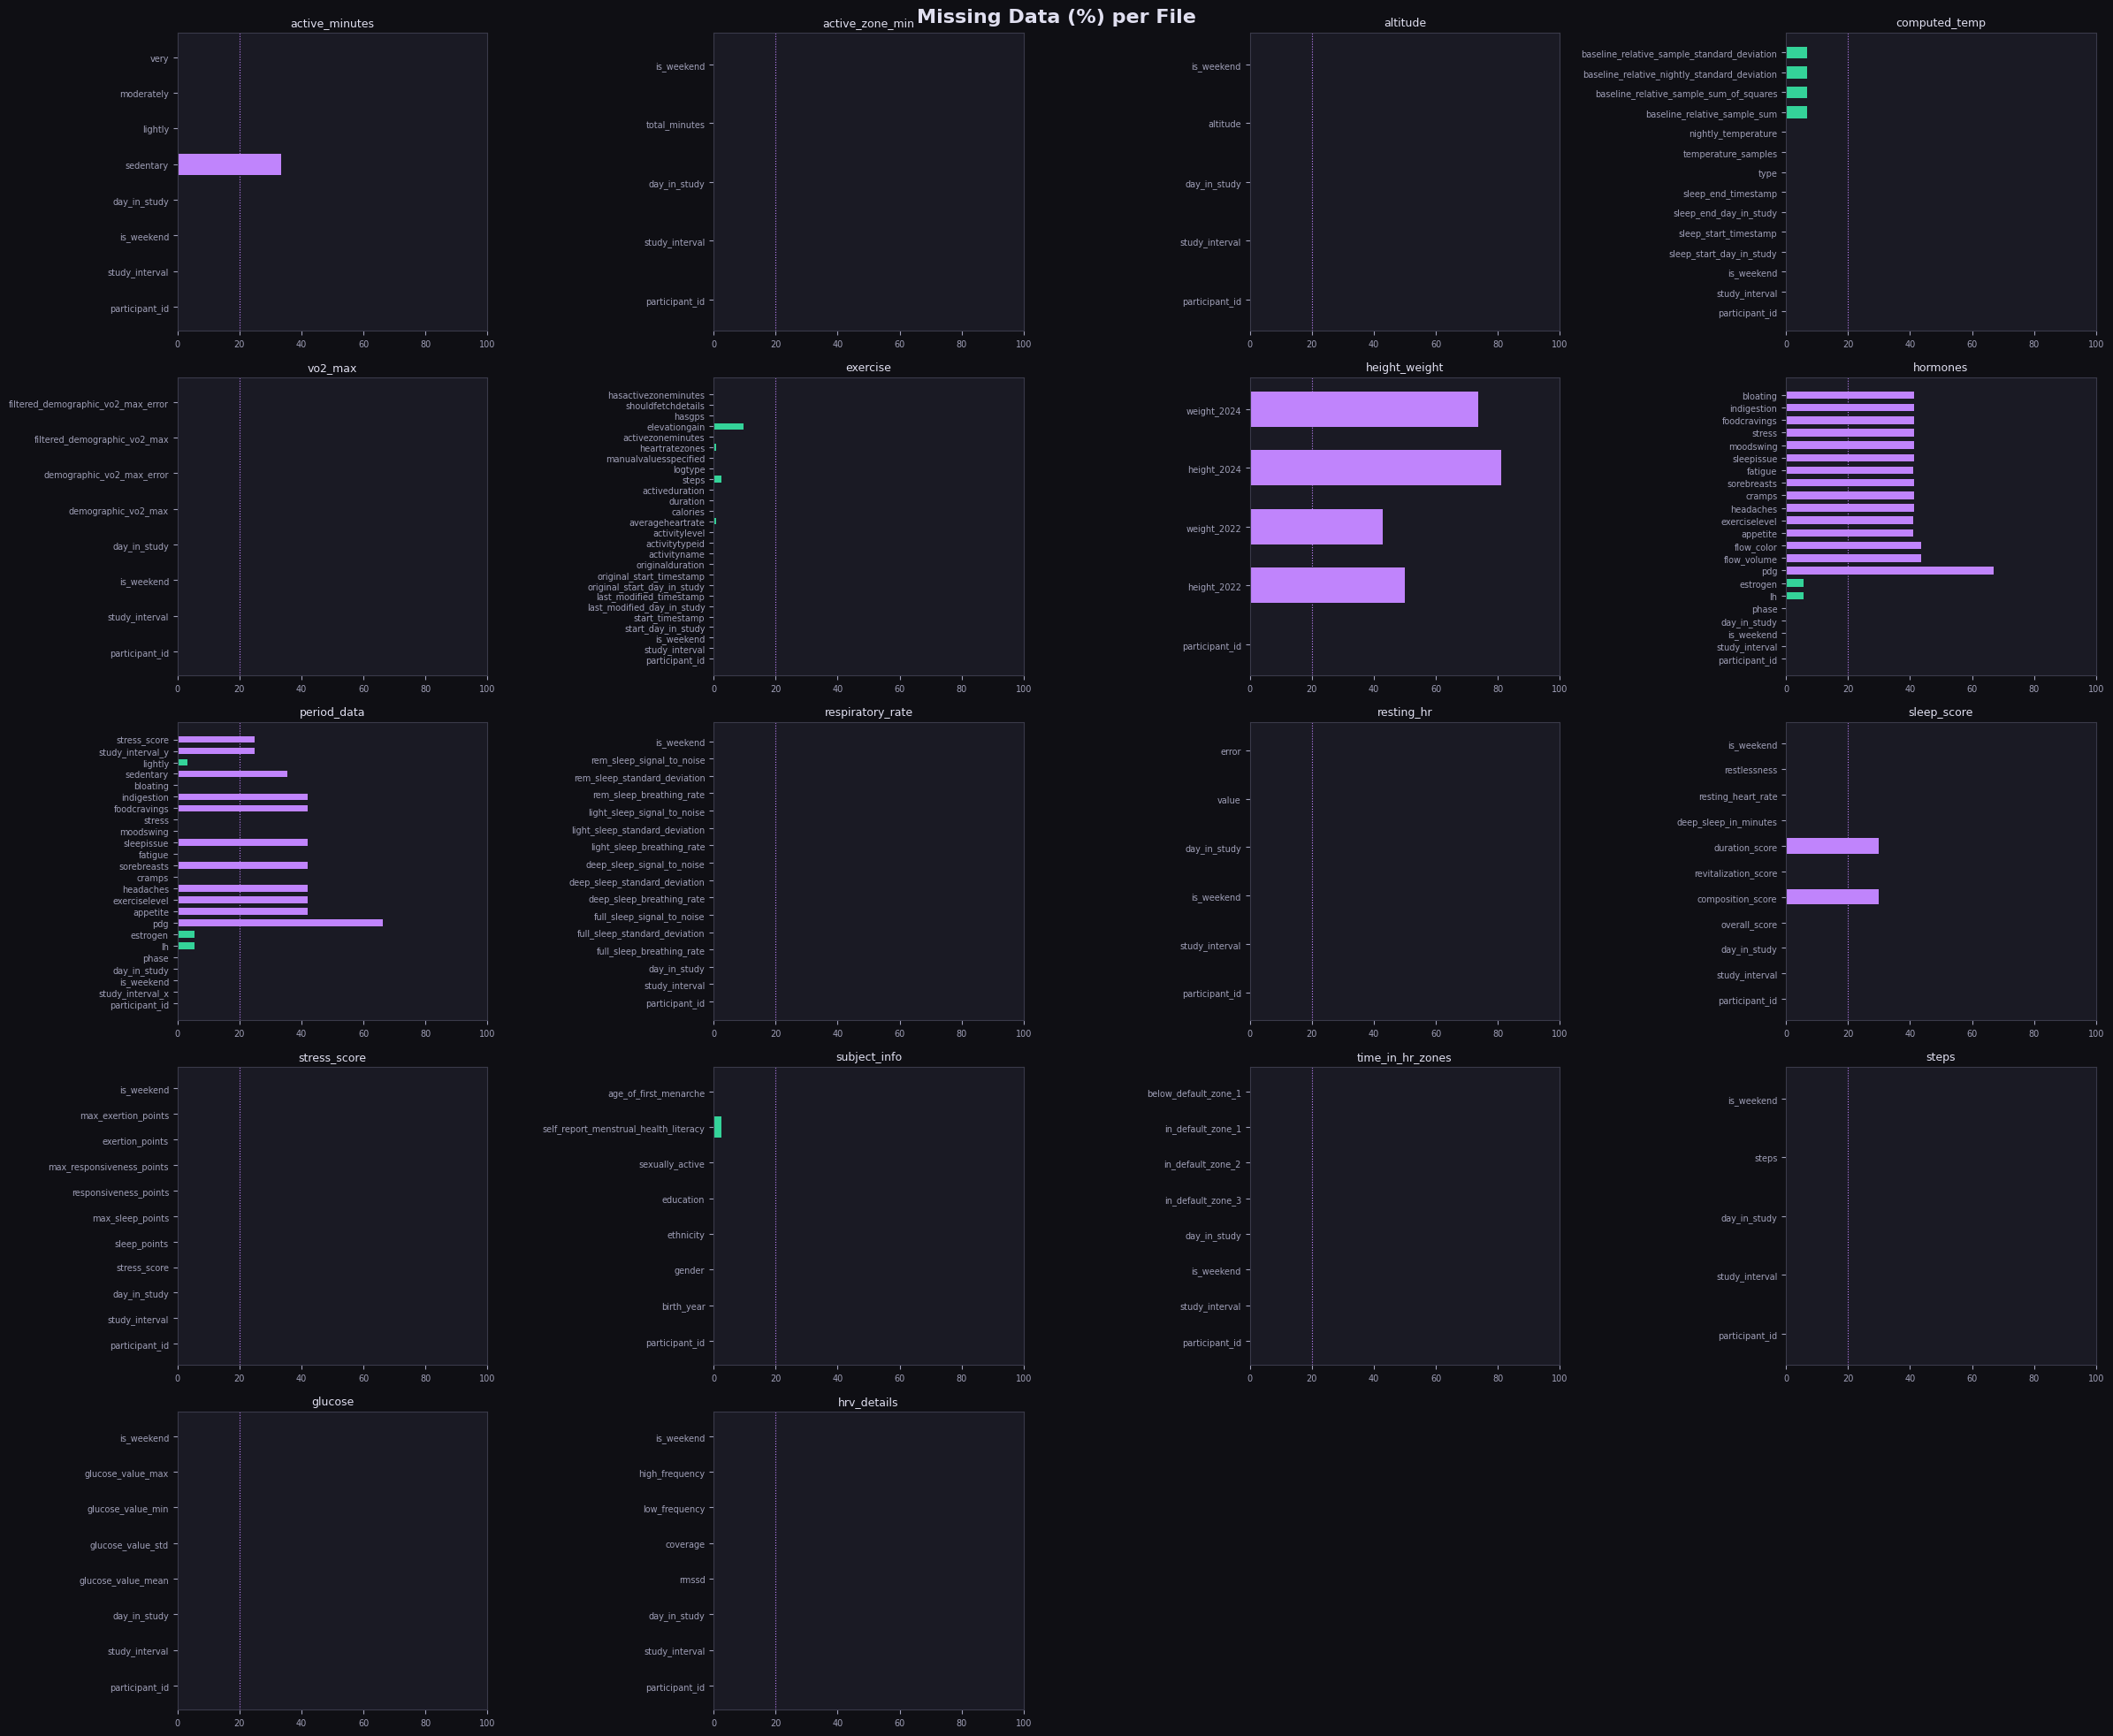

✓  Saved: 01_missingness.png


In [25]:
keys = list(dfs.keys())
n_files = len(keys)
cols_per_row = 4
n_rows = (n_files + cols_per_row - 1) // cols_per_row

fig, axes = plt.subplots(n_rows, cols_per_row,
                          figsize=(cols_per_row * 6, n_rows * 4))
axes = axes.flatten()
fig.suptitle("Missing Data (%) per File", fontsize=16,
             color="#e0dff0", fontweight="bold")

for i, key in enumerate(keys):
    ax = axes[i]
    miss = dfs[key].isnull().mean().mul(100)
    colors = [ACCENT if v > 20 else ACCENT3 if v > 0 else "#2a2a3a"
              for v in miss.values]
    ax.barh(miss.index, miss.values, color=colors, height=0.6)
    ax.set_xlim(0, 100)
    ax.set_title(key, fontsize=9, color="#e0dff0")
    ax.tick_params(labelsize=7)
    ax.axvline(20, color=ACCENT, lw=0.8, linestyle=":")

for ax in axes[n_files:]:
    ax.set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "01_missingness.png", dpi=150,
            bbox_inches="tight", facecolor="#0f0f14")
plt.show()
print("✓  Saved: 01_missingness.png")



Hormone columns detected: ['lh', 'estrogen', 'pdg']


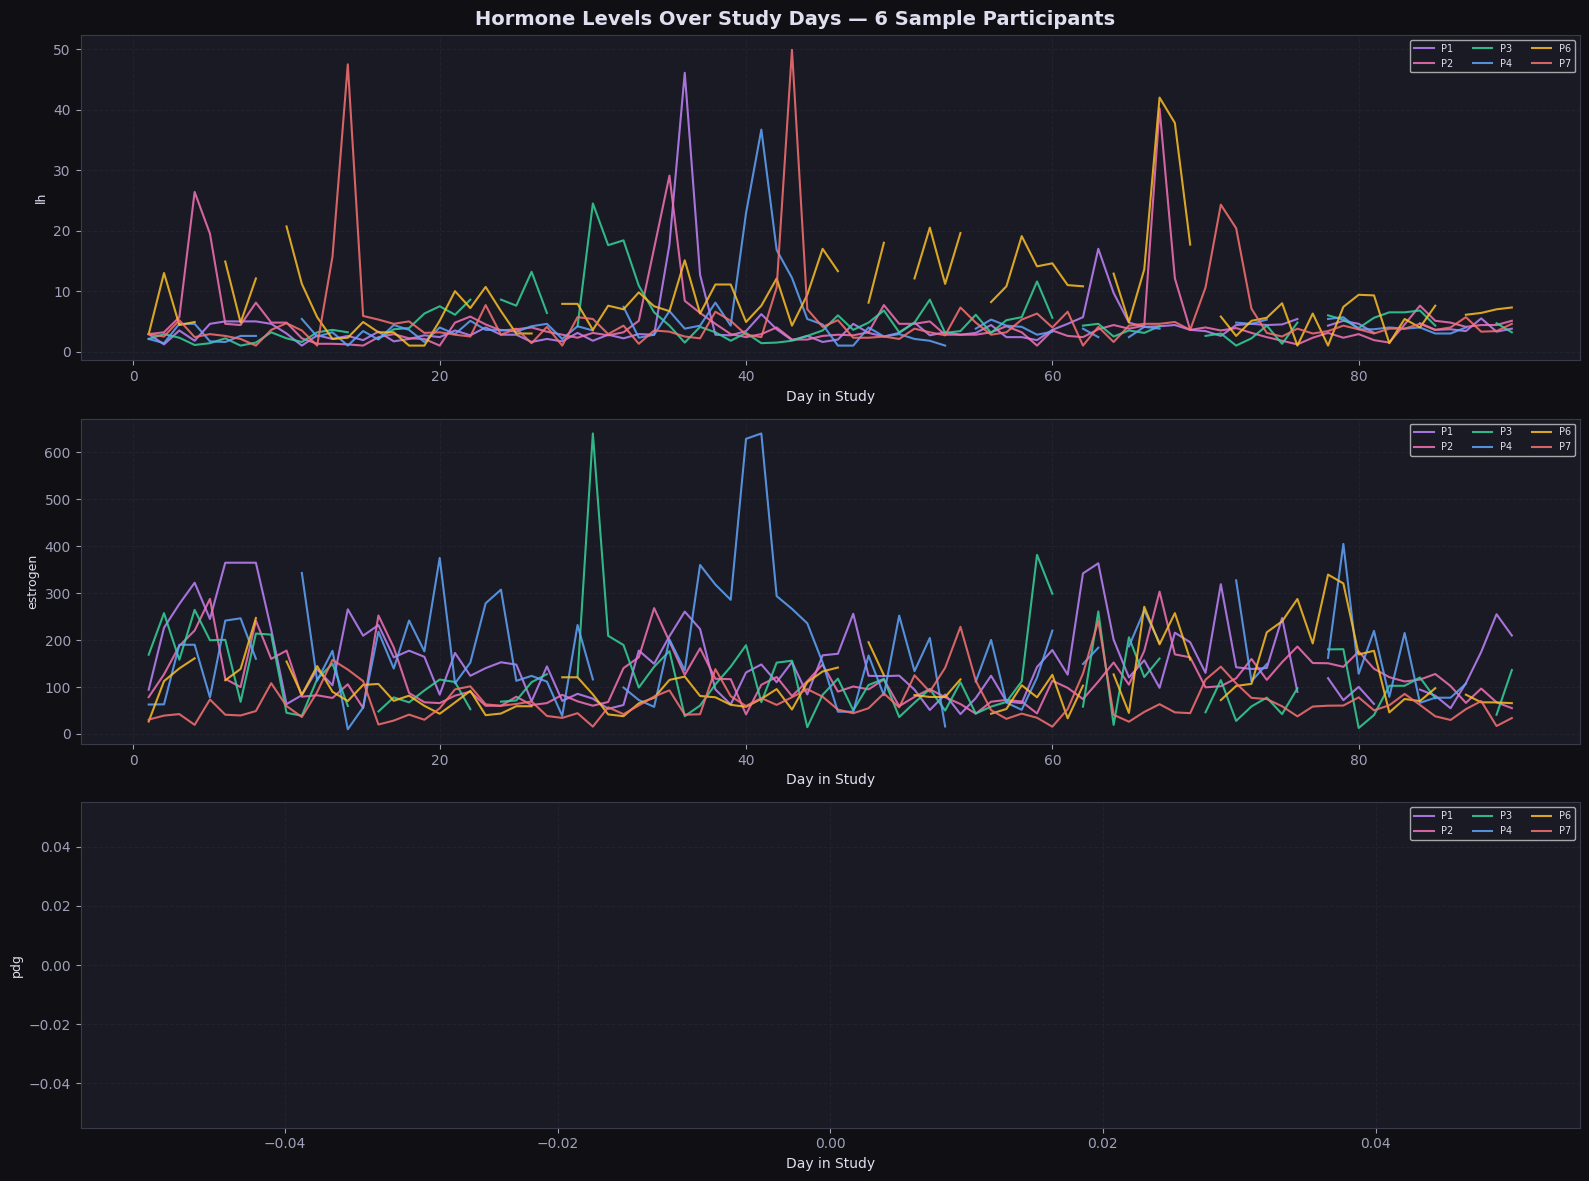

✓  Saved: 02_hormone_timeseries.png


In [26]:
if "hormones" in dfs:
    hor = dfs["hormones"].copy()

    hormone_cols = [c for c in hor.columns
                    if any(h in c.lower() for h in
                           ["lh","estrogen","pdg","fsh","progesterone"])]
    print(f"Hormone columns detected: {hormone_cols}")

    if hormone_cols and "participant_id" in hor.columns:
        sample_pids = hor["participant_id"].unique()[:6]
        fig, axes = plt.subplots(len(hormone_cols), 1,
                                 figsize=(16, 4 * len(hormone_cols)))
        if len(hormone_cols) == 1:
            axes = [axes]
        fig.suptitle("Hormone Levels Over Study Days — 6 Sample Participants",
                     fontsize=14, color="#e0dff0", fontweight="bold")

        for ax, hcol in zip(axes, hormone_cols):
            for i, pid in enumerate(sample_pids):
                sub = hor[hor["participant_id"] == pid].sort_values("day_in_study")
                ax.plot(sub["day_in_study"], sub[hcol],
                        color=PALETTE[i % len(PALETTE)],
                        alpha=0.85, linewidth=1.5, label=f"P{pid}")
            ax.set_ylabel(hcol, fontsize=9)
            ax.set_xlabel("Day in Study")
            ax.legend(fontsize=7, ncol=3)
            ax.grid(True)

        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / "02_hormone_timeseries.png", dpi=150,
                    bbox_inches="tight", facecolor="#0f0f14")
        plt.show()
        print("✓  Saved: 02_hormone_timeseries.png")


In [27]:
if "period_data" in dfs:
    pd_df = dfs["period_data"].copy()
    print("processed_period_data columns:", list(pd_df.columns))
    display(pd_df.head(10))
    print(f"\nShape        : {pd_df.shape}")
    print(f"Participants : {pd_df['participant_id'].nunique()
                            if 'participant_id' in pd_df.columns else 'N/A'}")
    print(f"\nMissing %:")
    print(pd_df.isnull().mean().mul(100).round(1).to_string())

    # Plot cycle lengths if a relevant column exists
    cycle_col = next((c for c in pd_df.columns
                      if any(k in c.lower() for k in
                             ["cycle_length","cycle_len","period_length"])), None)
    if cycle_col and "participant_id" in pd_df.columns:
        # One row per cycle — deduplicate
        cycle_info = pd_df.drop_duplicates(
            subset=["participant_id", cycle_col])

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        fig.suptitle("Cycle Length Distribution", fontsize=13,
                     color="#e0dff0", fontweight="bold")

        axes[0].hist(cycle_info[cycle_col].dropna(), bins=20,
                     color=ACCENT, edgecolor="#0f0f14", alpha=0.9)
        axes[0].set_xlabel("Cycle Length (days)")
        axes[0].set_ylabel("Count")
        axes[0].set_title("All participants", fontsize=10)

        per_p = (cycle_info.groupby("participant_id")[cycle_col]
                 .mean().sort_values())
        axes[1].barh(per_p.index.astype(str), per_p.values,
                     color=ACCENT2, edgecolor="#0f0f14", alpha=0.9)
        axes[1].set_xlabel("Mean Cycle Length (days)")
        axes[1].set_title("Per participant mean", fontsize=10)
        axes[1].tick_params(labelsize=6)

        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / "03_cycle_lengths.png", dpi=150,
                    bbox_inches="tight", facecolor="#0f0f14")
        plt.show()
        print("✓  Saved: 03_cycle_lengths.png")
    else:
        print(f"\n  No cycle_length column found.")
        print(f"  Available columns: {list(pd_df.columns)}")
else:
    print("⚠  processed_period_data.csv not loaded")

processed_period_data columns: ['participant_id', 'study_interval_x', 'is_weekend', 'day_in_study', 'phase', 'lh', 'estrogen', 'pdg', 'appetite', 'exerciselevel', 'headaches', 'cramps', 'sorebreasts', 'fatigue', 'sleepissue', 'moodswing', 'stress', 'foodcravings', 'indigestion', 'bloating', 'sedentary', 'lightly', 'study_interval_y', 'stress_score']


,participant_id,study_interval_x,is_weekend,day_in_study,phase,lh,estrogen,pdg,appetite,exerciselevel,headaches,cramps,sorebreasts,fatigue,sleepissue,moodswing,stress,foodcravings,indigestion,bloating,sedentary,lightly,study_interval_y,stress_score
0,1,2022,True,1,Follicular,2.900,94.200,NaN,Low,Low,High,1.000,Very Low/Little,3.000,Low,1.000,2.000,Very Low/Little,Very Low/Little,1.000,753.000,64.000,NaN,NaN
1,1,2022,False,2,Follicular,1.200,226.300,NaN,Low,Low,Very High,1.000,Very Low/Little,3.000,Very High,1.000,2.000,Very Low/Little,Very Low/Little,1.000,855.000,74.000,NaN,NaN
2,1,2022,False,3,Follicular,3.500,276.800,NaN,Very Low,Very Low,High,1.000,Very Low/Little,4.000,Very High,1.000,1.000,Very Low/Little,Very Low/Little,1.000,751.000,134.000,NaN,NaN
3,1,2022,False,4,Fertility,1.800,322.100,NaN,Low,Low,Very Low/Little,1.000,Very Low/Little,3.000,Very High,1.000,1.000,Very Low/Little,Very Low/Little,1.000,905.000,86.000,NaN,NaN
4,1,2022,False,5,Fertility,4.600,244.900,NaN,Very Low,Very Low,Very Low/Little,1.000,Very Low/Little,3.000,High,1.000,1.000,Very Low/Little,Very Low/Little,1.000,1430.000,10.000,NaN,NaN
5,1,2022,False,6,Fertility,5.000,364.700,NaN,Low,Low,Very Low/Little,1.000,Very Low/Little,2.000,Moderate,1.000,1.000,Very Low/Little,Very Low/Little,1.000,1036.000,28.000,NaN,NaN
6,1,2022,True,7,Fertility,5.000,364.700,NaN,Moderate,Moderate,Very Low/Little,1.000,Very Low/Little,1.000,Low,1.000,1.000,Very Low/Little,Very Low/Little,1.000,805.000,117.000,NaN,NaN
7,1,2022,True,8,Fertility,5.000,364.700,NaN,Moderate,Moderate,Very Low/Little,1.000,Very Low/Little,1.000,Low,1.000,1.000,Very Low/Little,Very Low/Little,1.000,1292.000,148.000,NaN,NaN
8,1,2022,False,9,Fertility,4.600,222.300,NaN,Very Low,Very Low,Very Low/Little,1.000,Very Low/Little,1.000,Very Low/Little,1.000,1.000,Very Low/Little,Very Low/Little,1.000,858.000,53.000,NaN,NaN
9,1,2022,False,10,Luteal,3.000,63.600,NaN,Very Low,Very Low,Very Low/Little,1.000,Very Low/Little,1.000,Very Low/Little,1.000,2.000,Very Low/Little,Very Low/Little,1.000,758.000,61.000,NaN,NaN



Shape        : (5730, 24)
Participants : 42

Missing %:
participant_id      0.000
study_interval_x    0.000
is_weekend          0.000
day_in_study        0.000
phase               0.000
lh                  5.600
estrogen            5.600
pdg                66.300
appetite           41.900
exerciselevel      41.900
headaches          41.900
cramps              0.000
sorebreasts        41.900
fatigue             0.000
sleepissue         41.900
moodswing           0.000
stress              0.000
foodcravings       41.900
indigestion        42.000
bloating            0.000
sedentary          35.500
lightly             3.100
study_interval_y   24.800
stress_score       24.800

  No cycle_length column found.
  Available columns: ['participant_id', 'study_interval_x', 'is_weekend', 'day_in_study', 'phase', 'lh', 'estrogen', 'pdg', 'appetite', 'exerciselevel', 'headaches', 'cramps', 'sorebreasts', 'fatigue', 'sleepissue', 'moodswing', 'stress', 'foodcravings', 'indigestion', 'bloating', 'sed

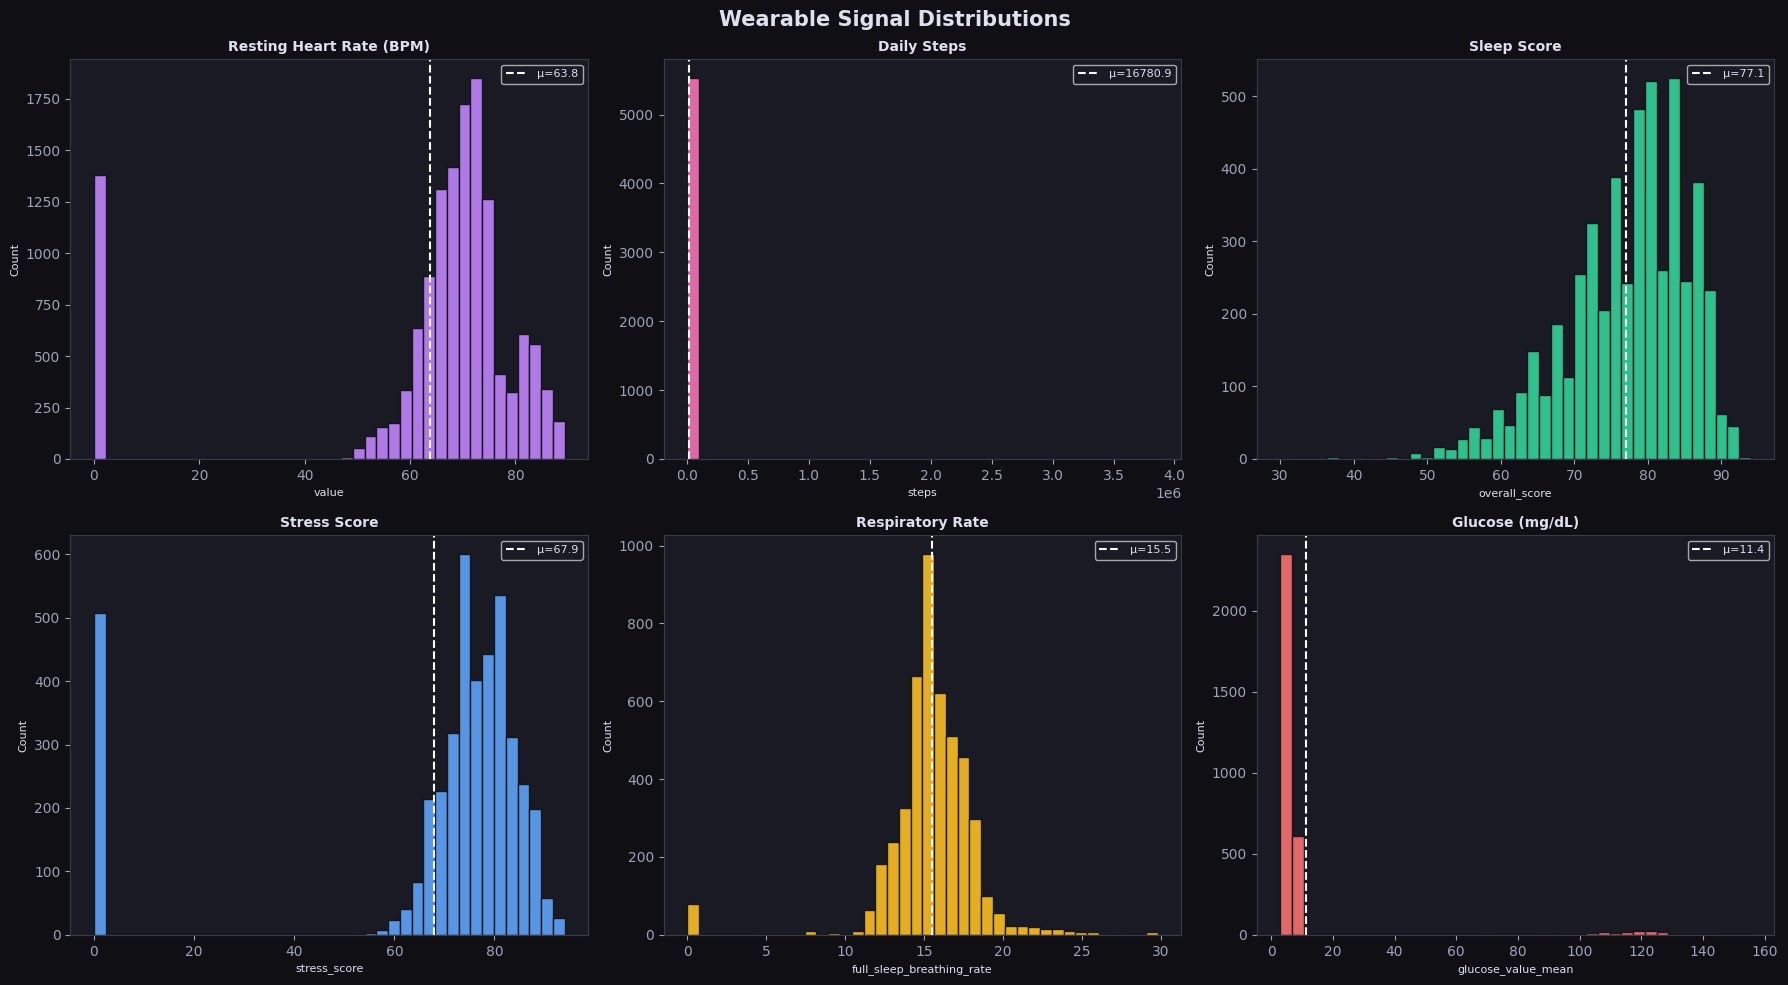

✓  Saved: 04_signal_distributions.png


In [30]:
GROUP_KEYS = ["participant_id", "study_interval", "day_in_study"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
fig.suptitle("Wearable Signal Distributions", fontsize=15,
             color="#e0dff0", fontweight="bold")

plot_targets = [
    ("resting_hr",      "Resting Heart Rate (BPM)", ACCENT),
    ("steps",           "Daily Steps",               ACCENT2),
    ("sleep_score",     "Sleep Score",               ACCENT3),
    ("stress_score",    "Stress Score",              "#60a5fa"),
    ("respiratory_rate","Respiratory Rate",          "#fbbf24"),
    ("glucose",         "Glucose (mg/dL)",           "#f87171"),
]

for ax, (key, title, color) in zip(axes, plot_targets):
    if key not in dfs:
        ax.set_title(f"{title}\n(not loaded)", fontsize=9, color="#a0a0b8")
        continue
    df = dfs[key]
    num_cols = [c for c in df.select_dtypes(include=np.number).columns
                if c not in GROUP_KEYS]
    if not num_cols:
        ax.set_title(f"{title}\n(no numeric cols)", fontsize=9)
        continue
    col = num_cols[0]
    data = df[col].dropna()
    ax.hist(data, bins=40, color=color, edgecolor="#0f0f14", alpha=0.9)
    ax.axvline(data.mean(), color="white", lw=1.5, linestyle="--",
               label=f"μ={data.mean():.1f}")
    ax.set_title(title, fontsize=10, color="#e0dff0", fontweight="bold")
    ax.set_xlabel(col, fontsize=8)
    ax.set_ylabel("Count", fontsize=8)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "04_signal_distributions.png", dpi=150,
            bbox_inches="tight", facecolor="#0f0f14")
plt.show()
print("✓  Saved: 04_signal_distributions.png")

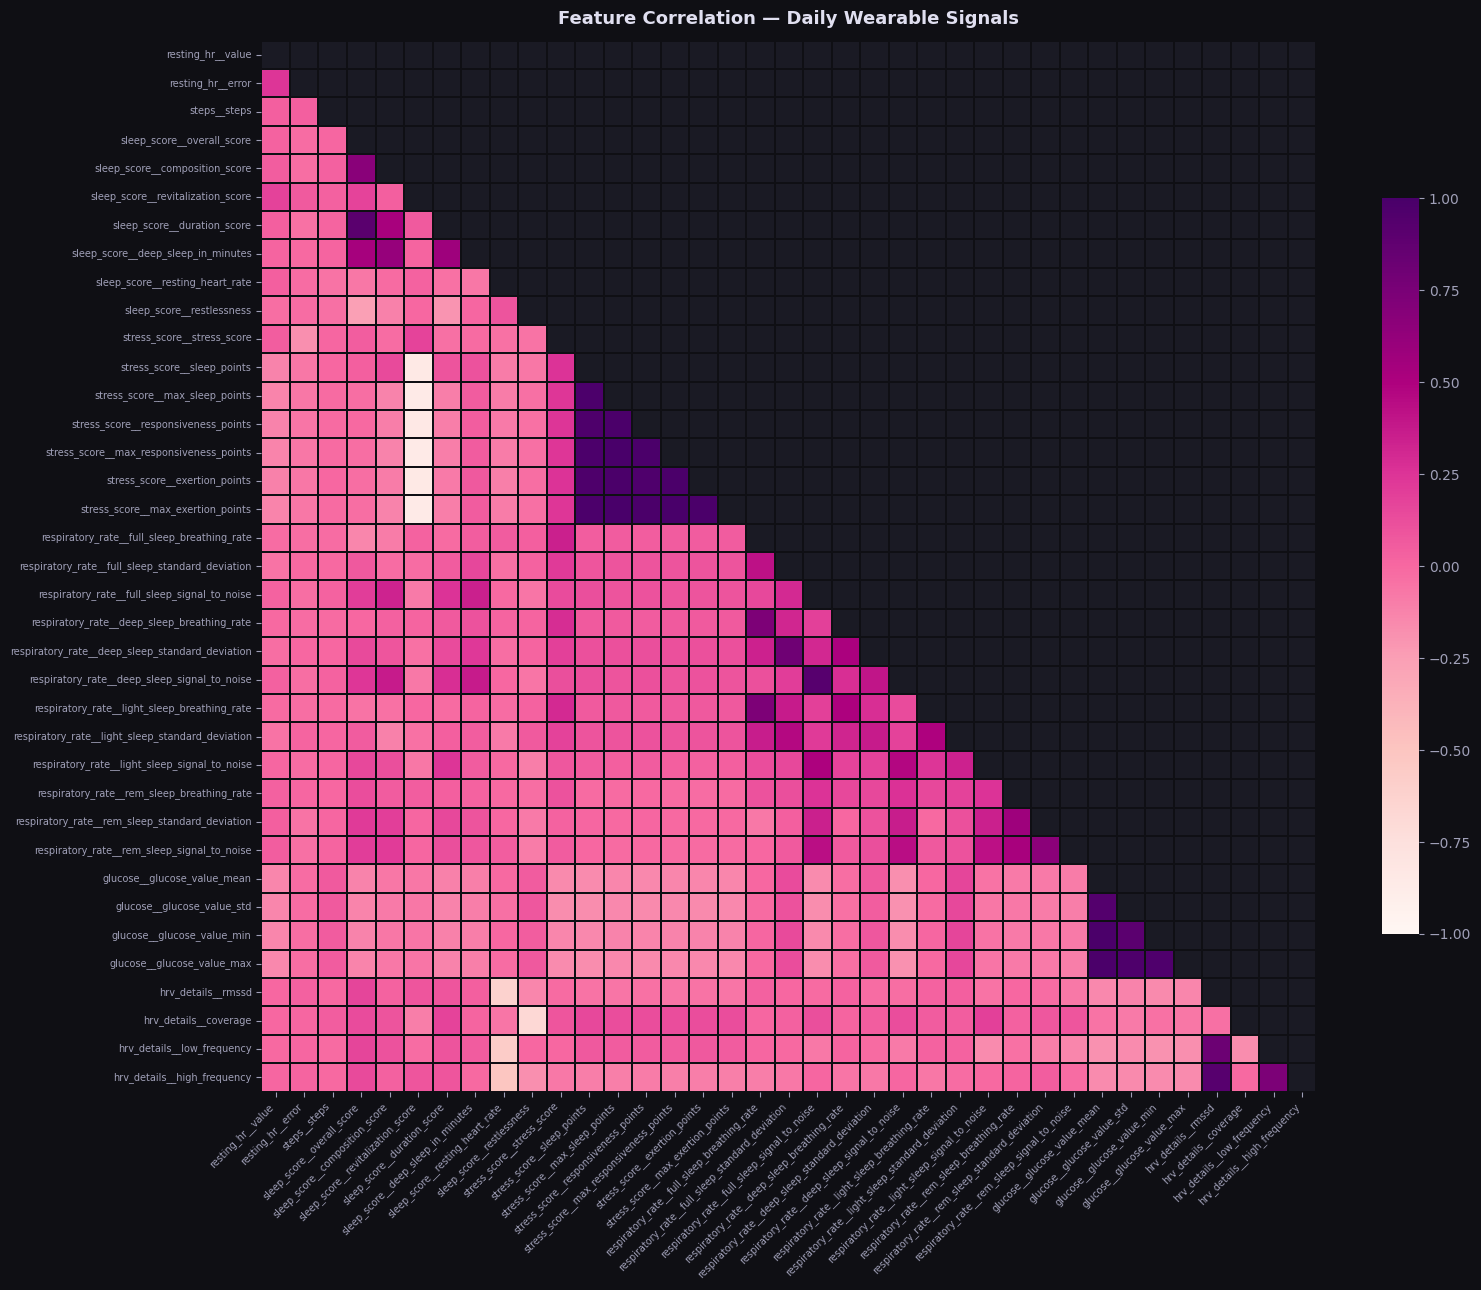

✓  Saved: 06_correlation_heatmap.png


In [31]:
GROUP_KEYS = ["participant_id", "study_interval", "day_in_study"]
corr_keys = ["resting_hr","steps","sleep_score",
             "stress_score","respiratory_rate","glucose","hrv_details"]
merge_list = []

for k in corr_keys:
    if k not in dfs:
        continue
    df = dfs[k].copy()
    gk = [c for c in GROUP_KEYS if c in df.columns]
    if len(gk) < 2:
        continue
    num_cols = [c for c in df.select_dtypes(include=np.number).columns
                if c not in GROUP_KEYS]
    df = df[gk + num_cols].copy()
    df.rename(columns={c: f"{k}__{c}" for c in num_cols}, inplace=True)
    merge_list.append((gk, df))

if merge_list:
    combined = merge_list[0][1]
    gk0 = merge_list[0][0]
    for gk, mdf in merge_list[1:]:
        on_cols = list(set(gk0) & set(gk))
        combined = pd.merge(combined, mdf, on=on_cols, how="outer")

    num_combined = combined.select_dtypes(include=np.number).drop(
        columns=[c for c in GROUP_KEYS if c in combined.columns],
        errors="ignore")
    corr = num_combined.corr()

    fig, ax = plt.subplots(figsize=(16, 13))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, cmap="RdPu", center=0, vmin=-1, vmax=1,
                ax=ax, linewidths=0.3, linecolor="#0f0f14",
                cbar_kws={"shrink": 0.7})
    ax.set_title("Feature Correlation — Daily Wearable Signals",
                 fontsize=13, color="#e0dff0", fontweight="bold", pad=12)
    plt.xticks(rotation=45, ha="right", fontsize=7)
    plt.yticks(fontsize=7)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "06_correlation_heatmap.png", dpi=150,
                bbox_inches="tight", facecolor="#0f0f14")
    plt.show()
    print("✓  Saved: 06_correlation_heatmap.png")

In [12]:
print("[Step 1] Building master feature dataframe…")
print(f"         Join key: {GROUP_KEYS}")

# Files that join on participant only (no day key)
STATIC_FILES = {"subject_info", "height_weight"}

# ── Anchor: hormones (has phase + hormone ground truth) ───
master = dfs["hormones"].copy()
# Prefix all non-key numeric + categorical cols
key_cols = [c for c in GROUP_KEYS if c in master.columns] + ["is_weekend","phase"]
for col in list(master.columns):
    if col not in key_cols and col != "participant_id":
        master.rename(columns={col: f"hor__{col}"}, inplace=True)
print(f"  Anchor (hormones)   : {master.shape}")

# ── Merge period_data ─────────────────────────────────────
if "period_data" in dfs:
    pdf = dfs["period_data"].copy()
    gk = [c for c in GROUP_KEYS if c in pdf.columns]
    num_p = [c for c in pdf.select_dtypes(include=np.number).columns
             if c not in GROUP_KEYS]
    cat_p = [c for c in pdf.select_dtypes(exclude=np.number).columns
             if c not in GROUP_KEYS + ["participant_id","is_weekend"]]
    feat_cols = num_p + cat_p
    if feat_cols:
        pdf = pdf[gk + ["participant_id"] + feat_cols].copy()
        pdf.rename(columns={c: f"period__{c}" for c in feat_cols},
                   inplace=True)
        master = pd.merge(master, pdf, on=["participant_id"] + gk, how="left")
        print(f"  + period_data       : {master.shape}")

# ── Merge all daily wearable files ───────────────────────
SKIP = {"hormones", "period_data"} | STATIC_FILES

for key, df in dfs.items():
    if key in SKIP:
        continue
    gk = [c for c in GROUP_KEYS if c in df.columns]
    if "participant_id" not in df.columns or len(gk) < 2:
        continue
    num_cols = [c for c in df.select_dtypes(include=np.number).columns
                if c not in GROUP_KEYS]
    if not num_cols:
        continue
    df_m = df[["participant_id"] + gk + num_cols].copy()
    df_m.rename(columns={c: f"{key}__{c}" for c in num_cols}, inplace=True)
    master = pd.merge(master, df_m,
                      on=["participant_id"] + gk, how="left")
    print(f"  + {key:<20} : {master.shape}")

# ── Merge static files (participant only) ────────────────
for key in STATIC_FILES:
    if key not in dfs:
        continue
    df = dfs[key]
    if "participant_id" not in df.columns:
        continue
    num_cols = [c for c in df.select_dtypes(include=np.number).columns
                if "participant" not in c.lower()]
    if not num_cols:
        continue
    df_m = df[["participant_id"] + num_cols].copy()
    df_m.rename(columns={c: f"{key}__{c}" for c in num_cols}, inplace=True)
    master = pd.merge(master, df_m, on="participant_id", how="left")
    print(f"  + {key:<20} : {master.shape}")

print(f"\n  ✓  Master shape     : {master.shape}")
print(f"     Participants    : {master['participant_id'].nunique()}")
print(f"     Numeric columns : {master.select_dtypes(include=np.number).shape[1]}")
display(master.head(3))


[Step 1] Building master feature dataframe…
         Join key: ['participant_id', 'study_interval', 'day_in_study']


NameError: name 'dfs' is not defined

In [13]:
print("[Step 2] Cycle-day and phase feature engineering…")

# ── Use day_in_study as cycle-day proxy ──────────────────
# day_in_study resets each study_interval → use directly
if "day_in_study" in master.columns:
    PERIOD = 28
    master["cycle_day_sin"] = np.sin(2*np.pi * master["day_in_study"] / PERIOD)
    master["cycle_day_cos"] = np.cos(2*np.pi * master["day_in_study"] / PERIOD)
    print("  ✓  Cyclic encoding: day_in_study → sin/cos (period=28)")

# ── Encode menstrual phase as ordinal ────────────────────
if "phase" in master.columns:
    PHASE_ORDER = {
        "Menstrual"   : 0,
        "Follicular"  : 1,
        "Ovulation"   : 2,
        "Luteal"      : 3,
    }
    # Check what phase names actually exist
    actual_phases = master["phase"].dropna().unique()
    print(f"  Phases found: {actual_phases}")

    # Map — case-insensitive
    phase_map = {p: PHASE_ORDER.get(p, PHASE_ORDER.get(p.capitalize(), -1))
                 for p in actual_phases}
    print(f"  Phase mapping: {phase_map}")
    master["phase_encoded"] = master["phase"].map(phase_map)

    # One-hot encode phase as well (useful for some models)
    phase_dummies = pd.get_dummies(master["phase"], prefix="phase")
    master = pd.concat([master, phase_dummies], axis=1)
    print(f"  ✓  Phase encoded (ordinal + one-hot)")
    print(f"     New columns: {list(phase_dummies.columns)}")

# ── is_weekend as int ────────────────────────────────────
if "is_weekend" in master.columns:
    master["is_weekend"] = master["is_weekend"].astype(int)
    print("  ✓  is_weekend → int")

print(f"\n  Master shape after feature engineering: {master.shape}")


[Step 2] Cycle-day and phase feature engineering…


NameError: name 'master' is not defined

In [ ]:
# Identify numeric feature columns (exclude keys and encoded targets)
EXCLUDE = set(GROUP_KEYS) | {"participant_id", "phase_encoded"}
num_feat_cols = [c for c in master.select_dtypes(include=np.number).columns
                 if c not in EXCLUDE]

# ── Outlier capping (IQR ×1.5) ───────────────────────────
print("[Step 3] Outlier capping (Winsorisation at IQR ×1.5)…")
capped = {}
for col in num_feat_cols:
    s = master[col].dropna()
    if len(s) < 4:
        continue
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    n = ((master[col] < lo) | (master[col] > hi)).sum()
    if n:
        master[col] = master[col].clip(lo, hi)
        capped[col] = n

print(f"  Capped {len(capped)} columns. Top 5:")
for col, n in sorted(capped.items(), key=lambda x: -x[1])[:5]:
    print(f"    {col:<55} {n} values")

# ── Missing value imputation ─────────────────────────────
print("\n[Step 4] Imputing missing values…")
miss_pct = master[num_feat_cols].isnull().mean().mul(100)
drop_cols = miss_pct[miss_pct > 50].index.tolist()
imp_cols  = miss_pct[(miss_pct > 0) & (miss_pct <= 50)].index.tolist()

print(f"  Dropping  (>50% missing) : {len(drop_cols)} columns")
print(f"  Imputing  (≤50% missing) : {len(imp_cols)} columns")
print(f"  Complete  (0%  missing)  : {(miss_pct == 0).sum()} columns")

master.drop(columns=drop_cols, inplace=True)
num_feat_cols = [c for c in num_feat_cols if c not in drop_cols]
imp_cols = [c for c in imp_cols if c in master.columns]

if imp_cols:
    master = master.sort_values(["participant_id","study_interval","day_in_study"])
    # Per-participant forward-fill then backward-fill (respects time order)
    master[imp_cols] = (master.groupby("participant_id")[imp_cols]
                        .transform(lambda x: x.ffill().bfill()))
    # KNN for any remaining NaN
    still_miss = [c for c in imp_cols if master[c].isnull().any()]
    if still_miss:
        print(f"  KNN imputing {len(still_miss)} residual columns…")
        imputer = KNNImputer(n_neighbors=5)
        master[still_miss] = imputer.fit_transform(master[still_miss])

print(f"  Remaining NaN: {master[num_feat_cols].isnull().sum().sum()}")


In [ ]:
print("[Step 5] Per-participant Z-score normalisation…")

# Keep hormone, period, and phase cols in raw scale
skip_scale = set()
for prefix in ("hor__", "period__", "phase"):
    skip_scale.update([c for c in master.columns if c.startswith(prefix)])
skip_scale.update(EXCLUDE | {"is_weekend","cycle_day_sin","cycle_day_cos"})

scale_cols = [c for c in num_feat_cols if c not in skip_scale]

def participant_zscore(group):
    for col in scale_cols:
        if col in group.columns:
            mu, sigma = group[col].mean(), group[col].std()
            if sigma > 0:
                group[col] = (group[col] - mu) / sigma
    return group

master = master.groupby("participant_id",
                         group_keys=False).apply(participant_zscore)

print(f"  ✓  Normalised {len(scale_cols)} wearable feature columns")
print(f"     (hormone, period, phase cols kept in raw scale)")

# ── Final summary ────────────────────────────────────────
print(f"\n{'═'*52}")
print(f"  MASTER DATAFRAME READY")
print(f"{'═'*52}")
print(f"  Shape             : {master.shape}")
print(f"  Participants      : {master['participant_id'].nunique()}")
print(f"  Study intervals   : {sorted(master['study_interval'].unique())}")
print(f"  Day range         : {master['day_in_study'].min()} → "
      f"{master['day_in_study'].max()}")
print(f"  Total NaN         : {master.isnull().sum().sum()}")
print(f"  Numeric cols      : {master.select_dtypes(include=np.number).shape[1]}")
print(f"{'═'*52}")
display(master.head())

In [ ]:
# ── Main feature file → feed into your model ─────────────
out_path = OUTPUT_DIR / "master_daily_features.csv"
master.to_csv(out_path, index=False)
print(f"✓  master_daily_features.csv")
print(f"   {master.shape[0]} rows × {master.shape[1]} cols")
print(f"   → {out_path}")

# ── Per-participant files → for LOSO cross-validation ────
per_p_dir = OUTPUT_DIR / "per_participant"
per_p_dir.mkdir(exist_ok=True)
for pid, grp in master.groupby("participant_id"):
    (grp.sort_values(["study_interval","day_in_study"])
        .to_csv(per_p_dir / f"participant_{pid}.csv", index=False))
print(f"\n✓  Per-participant CSVs → {per_p_dir}/")

# ── Column manifest → reference for your model code ──────
manifest = pd.DataFrame({
    "column"  : master.columns.tolist(),
    "dtype"   : master.dtypes.astype(str).tolist(),
    "missing%": master.isnull().mean().mul(100).round(2).tolist(),
    "source"  : [
        "hormone"  if c.startswith("hor__")
        else "period"  if c.startswith("period__")
        else "phase"   if c.startswith("phase")
        else "subject" if c.startswith("subject_info") or c.startswith("height_weight")
        else c.split("__")[0] if "__" in c
        else "meta"
        for c in master.columns
    ]
})
manifest.to_csv(OUTPUT_DIR / "column_manifest.csv", index=False)

print(f"\n✓  column_manifest.csv → {OUTPUT_DIR}/")
print(f"\n   Column sources breakdown:")
print(manifest["source"].value_counts().to_string())

print(f"\n\n🎉  PIPELINE COMPLETE")
print(f"   Load master_daily_features.csv into your model")
print(f"   Key columns for your model:")
print(f"     Input features : all wearable__ columns (normalised)")
print(f"     Hormone targets: hor__lh, hor__estrogen, hor__pdg")
print(f"     Phase target   : phase_encoded (0=Menstrual→3=Luteal)")
print(f"     Time encoding  : cycle_day_sin, cycle_day_cos")